# Mathematical Accuracy Analysis

When we sum the total death counts from each parish (by plague and by all causes), how does that compare to the sum of the four subtotals calculated in the 17th/18th centuries and recorded in the Bills of Mortality? In other words, how accurate was the contemporary mathematics of the bills?

This version of the code uses data processed for duplicates but not data marked illegible by transcribers.

# Fetch our data from Github

In [6]:
!wget https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/all_bills.csv

--2025-11-25 23:56:03--  https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/all_bills.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 134914826 (129M) [text/plain]
Saving to: ‘all_bills.csv’

all_bills.csv       100%[===================>] 128.66M  85.5MB/s    in 1.5s    

2025-11-25 23:56:05 (85.5 MB/s) - ‘all_bills.csv’ saved [134914826/134914826]



In [7]:
!wget https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/weeks.csv

--2025-11-25 23:56:05--  https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/weeks.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 516681 (505K) [text/plain]
Saving to: ‘weeks.csv’

weeks.csv           100%[===================>] 504.57K  --.-KB/s    in 0.07s   

2025-11-25 23:56:06 (7.41 MB/s) - ‘weeks.csv’ saved [516681/516681]



In [8]:
!wget https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/parishes.csv

--2025-11-25 23:56:06--  https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/parishes.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10851 (11K) [text/plain]
Saving to: ‘parishes.csv’

parishes.csv        100%[===================>]  10.60K  --.-KB/s    in 0.001s  

2025-11-25 23:56:06 (18.2 MB/s) - ‘parishes.csv’ saved [10851/10851]



In [9]:
!wget https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/subtotals.csv

--2025-11-25 23:56:06--  https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/subtotals.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8849190 (8.4M) [text/plain]
Saving to: ‘subtotals.csv.1’

subtotals.csv.1     100%[===================>]   8.44M  --.-KB/s    in 0.09s   

2025-11-25 23:56:06 (93.6 MB/s) - ‘subtotals.csv.1’ saved [8849190/8849190]



In [10]:
!wget https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/duplicate_bills_removable.csv

--2025-11-25 23:56:06--  https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/duplicate_bills_removable.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29509 (29K) [text/plain]
Saving to: ‘duplicate_bills_removable.csv.1’

duplicate_bills_rem 100%[===================>]  28.82K  --.-KB/s    in 0.003s  

2025-11-25 23:56:06 (8.70 MB/s) - ‘duplicate_bills_removable.csv.1’ saved [29509/29509]



# Prepare the libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from collections import defaultdict

# Configure plotting
plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (15, 8)
warnings.filterwarnings('ignore')

# Load and remove duplicates from bills data

In [12]:
# Read in the all_bills.csv and weeks.csv files
all_bills = pd.read_csv(Path('all_bills.csv'))
weeks = pd.read_csv(Path('weeks.csv'))

# Merge the two dataframes on 'joinid', bringing in only selected columns from weeks
bills = all_bills.merge(
    weeks[['joinid', 'start_day', 'end_day', 'start_month', 'end_month','week_number']],
    on='joinid',
    how='left'
)

# Convert start_day and end_day to integer (if not null)
bills['start_day'] = bills['start_day'].astype('Int64')
bills['end_day'] = bills['end_day'].astype('Int64')

# Join the parish IDs
parishes = pd.read_csv(Path('parishes.csv'))
bills = bills.merge(parishes, left_on='parish_id', right_on='id', how='left')

# remove general bills by removing all bills with 'week_number' > 55
bills = bills[bills['week_number'] <= 55]

# remove Westminster pesthouse counts, which are not included in bills' subotals
bills = bills[bills['parish_id'] != 19]

# return head() for bills, sorted by year
bills.sort_values('year').head(10)

,parish_id,count_type,count,year,joinid,bill_type,missing,illegible,source,unique_identifier,start_day,end_day,start_month,end_month,week_number,id,parish_name,canonical_name,bills_subunit
245827,3,plague,0,1635,1635112616351203,weekly,True,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50,3,Alhallows Great,All Hallows the Great,97 parishes within the walls
245826,3,buried,0,1635,1635112616351203,weekly,True,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50,3,Alhallows Great,All Hallows the Great,97 parishes within the walls
245825,2,plague,0,1635,1635112616351203,weekly,True,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50,2,Alhallows Breadstreet,All Hallows Bread Street,97 parishes within the walls
245824,2,buried,0,1635,1635112616351203,weekly,True,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50,2,Alhallows Breadstreet,All Hallows Bread Street,97 parishes within the walls
245852,35,buried,0,1635,1635112616351203,weekly,True,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50,35,St Austins Parish,St Austin,97 parishes within the walls
245853,35,plague,0,1635,1635112616351203,weekly,True,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50,35,St Austins Parish,St Austin,97 parishes within the walls
245854,36,buried,0,1635,1635112616351203,weekly,True,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50,36,St Bartholomew Exchange,St Bartholomew Exchange,97 parishes within the walls
245855,36,plague,0,1635,1635112616351203,weekly,True,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50,36,St Bartholomew Exchange,St Bartholomew Exchange,97 parishes within the walls
245856,39,buried,1,1635,1635112616351203,weekly,False,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50,39,St Bennet Fynck,St Benet Fink,97 parishes within the walls
245857,39,plague,0,1635,1635112616351203,weekly,True,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50,39,St Bennet Fynck,St Benet Fink,97 parishes within the walls


In [13]:
#print the total number of "weeks", including annual bills
num_unique_weeks = len(weeks)
print(f"Total number of unique weeks: {num_unique_weeks}")

#print the number of unique joinid in weeks
print(f"Total number of unique joinid in weeks: {weeks['joinid'].nunique()}")

#print the number of unique joinid in bills
print(f"Total number of unique joinid in bills: {bills['joinid'].nunique()}")

#identify joinid in weeks but not in bills
diff = set(weeks['joinid']) - set(bills['joinid'])

#print lenght of diff
print(f"Number of joinid in bills but not in weeks: {len(diff)}")

# print number of joinid in bills but not in weeks
# print(f"Joinid in bills but not in weeks: {set(weeks['joinid']) - set(bills['joinid'])}")

Total number of unique weeks: 5555
Total number of unique joinid in weeks: 5505
Total number of unique joinid in bills: 5219
Number of joinid in bills but not in weeks: 286


There are duplicate bills in the dataset which we remove before continuing. We prioritized retaining the British Library copy of the bill, then the Bodleian copy of the bill. If we'd had to choose between Queens College and Wellcome, we would have kept QC, but there were no duplicates with that pairing.

In [14]:
#read in the list of duplicate bills to remove
duplicate_bills = pd.read_csv(Path('duplicate_bills_removable.csv'))

#print the number of rows in duplicate_bills, should be 174
print(f"Number of rows in duplicate_bills: {len(duplicate_bills)}")

#print the number of unique joinid in duplicate_bills, there should be 10 less as 10 bills were included 3 times
print(f"Number of unique joinid in duplicate_bills: {len(duplicate_bills['joinid'].unique())}")

unique_joinid = duplicate_bills['joinid'].unique()

#export unique_joinid to excel
pd.DataFrame(unique_joinid, columns=['joinid']).to_csv('unique_joinid.csv', index=False)


Number of rows in duplicate_bills: 174
Number of unique joinid in duplicate_bills: 164


In [15]:
# With the duplicate_bills data ready, we need to match data in our bills
# dataframe where a duplicate_bill row = bill row.

# Create a duplication key we can match against in bills data frame
bills['duplication_key'] = (
    bills['unique_identifier'].astype(str) + '-' +
    bills['count_type'].astype(str) + '-' +
    bills['joinid'].astype(str)
)

bills.head()

,parish_id,count_type,count,year,joinid,bill_type,missing,illegible,source,unique_identifier,start_day,end_day,start_month,end_month,week_number,id,parish_name,canonical_name,bills_subunit,duplication_key
0,24,buried,0,1662,1662121616621223,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,16,23,December,December,1,24,St Alban Woodstreet,St Alban Wood Street,97 parishes within the walls,QC-1662-01-recto-buried-1662121616621223
1,24,plague,0,1662,1662121616621223,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,16,23,December,December,1,24,St Alban Woodstreet,St Alban Wood Street,97 parishes within the walls,QC-1662-01-recto-plague-1662121616621223
2,1,buried,1,1662,1662121616621223,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,16,23,December,December,1,1,Alhallows Barking,All Hallows Barking,97 parishes within the walls,QC-1662-01-recto-buried-1662121616621223
3,1,plague,0,1662,1662121616621223,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,16,23,December,December,1,1,Alhallows Barking,All Hallows Barking,97 parishes within the walls,QC-1662-01-recto-plague-1662121616621223
4,2,buried,1,1662,1662121616621223,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,16,23,December,December,1,2,Alhallows Breadstreet,All Hallows Bread Street,97 parishes within the walls,QC-1662-01-recto-buried-1662121616621223


In [16]:
# Create a duplication key we can match against in duplicate_bills data frame
duplicate_bills['duplication_key'] = (
    duplicate_bills['unique_identifier'].astype(str) + '-' +
    duplicate_bills['count_type'].astype(str) + '-' +
    duplicate_bills['joinid'].astype(str)
)

duplicate_bills.head()

,parish_id,count_type,count,year,joinid,bill_type,missing,illegible,source,unique_identifier,week_number,start_day,end_day,start_month,end_month,duplication_key
0,1,buried,0,1663,1663061616630623,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-27-recto,27,16,23,June,June,QC-1663-27-recto-buried-1663061616630623
1,1,buried,1,1663,1663062316630630,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-28-recto,28,23,30,June,June,QC-1663-28-recto-buried-1663062316630630
2,1,buried,2,1663,1663063016630707,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-29-recto,29,30,7,June,July,QC-1663-29-recto-buried-1663063016630707
3,1,buried,1,1663,1663070716630714,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-30-recto,30,7,14,July,July,QC-1663-30-recto-buried-1663070716630714
4,1,buried,1,1663,1663071416630721,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-31-recto,31,14,21,July,July,QC-1663-31-recto-buried-1663071416630721


Now we identify and filter out the duplicates. We also confirm we have not lost any weeks in the process.

In [17]:
# Filter out rows from 'bills' that have a unique_identifier present in duplicate_bills
bills_deduped = bills[~bills['duplication_key'].isin(duplicate_bills['duplication_key'])]

# Print the number of unique joinid in bills
print(f"Number of unique joinid in bills: {len(bills['joinid'].unique())}")

# Print the number of unique joinid in bills_deduped
print(f"Number of unique joinid in bills_deduped: {len(bills_deduped['joinid'].unique())}")

# Find the joinid that is not in the intersection of bills and bills_deduped
joinid_difference = set(bills['joinid'].unique()) - set(bills_deduped['joinid'].unique())

#print the first 10 joinid in joinid_difference
print(f"First 10 joinid in joinid_difference: {list(joinid_difference)[:10]}")

Number of unique joinid in bills: 5219
Number of unique joinid in bills_deduped: 5219
First 10 joinid in joinid_difference: []


# How many total weeks are in the dataset?

We want to know, first, how many weeks are in our entire dataset. Note that the number of unique weeks in weeks.csv includes general bills which are excluded from this analysis.

In [18]:
#print the total number of "weeks", including annual bills
num_unique_weeks = len(weeks)
print(f"Total number of unique weeks: {num_unique_weeks}")

#print the number of unique joinid in weeks
print(f"Total number of unique joinid in weeks: {weeks['joinid'].nunique()}")

#print the number of unique joinid in bills
print(f"Total number of unique joinid in bills: {bills['joinid'].nunique()}")

#identify joinid in weeks but not in bills to confirm missing bills are all general bills
diff = set(weeks['joinid']) - set(bills['joinid'])
print(f"Number of joinid in bills but not in weeks: {len(diff)}")

# print number of joinid in bills but not in weeks
# print(f"Joinid in bills but not in weeks: {set(weeks['joinid']) - set(bills['joinid'])}")

Total number of unique weeks: 5555
Total number of unique joinid in weeks: 5505
Total number of unique joinid in bills: 5219
Number of joinid in bills but not in weeks: 286


# Load and remove duplicates from the subtotals (within, without, out-parishes)

In [19]:
# We build the subtotals separately rather than handle in the notebook.
subtotals_df = pd.read_csv(Path('subtotals.csv'))

# Filter out christening data, which we are not using
subtotals_df = subtotals_df[(subtotals_df['count_type'] != 'christened')]
#subtotals_df.sort_values('year').tail(10)

# print the number if uniqueid in subtotals_df
print(f"Total number of unique joinid in subtotals: {subtotals_df['joinid'].nunique()}")

# identify and print joinid in subtotals_df but not in bills to confirm there are no missing bills
diff2 = set(subtotals_df['joinid']) - set(bills['joinid'])
print(f"Number of joinid in subtotals_df but not in bills: {len(diff2)}")
print(f"Joinid in subtotals_df but not in bills: {diff2}")

Total number of unique joinid in subtotals: 5315
Number of joinid in subtotals_df but not in bills: 96
Joinid in subtotals_df but not in bills: {1683121816841216, 1699121917001217, 1667121716681222, 1732121217331211, 1748121317491212, 1716121117171217, 1668122216691221, 1749121217501211, 1669122116701222, 1734121217351209, 1750121117511210, 1670122216711219, 1735120917361207, 1671121916721217, 1720121317211212, 1656121716571215, 1688121116891217, 1721121217221211, 1737121317381212, 1722121117231210, 1738121217391211, 1658121716591213, 1706121017071216, 1723121017241215, 1739121117401216, 1708121417091213, 1724121517251214, 1740121617411215, 1660121716611217, 1692121316931219, 1709121317101212, 1725121417261213, 1741121517421214, 1710121217111211, 1742121417431213, 1662121716631215, 1743121317441211, 1711121117121216, 1696121516971214, 1712121617131215, 1680121416811219, 1664121716651219, 1745121117461210, 1713121517141214, 1681121916821219, 1697121416981220, 1714121417151213, 173012151

In [20]:
# Create a duplication key we can match against in subtotals data frame
subtotals_df['duplication_key'] = (
    subtotals_df['unique_identifier'].astype(str) + '-' +
    subtotals_df['count_type'].astype(str) + '-' +
    subtotals_df['joinid'].astype(str)
)

# Filter out rows from 'subtotals_df' that have a unique_identifier present in duplicate_bills
subtotals_deduped = subtotals_df[~subtotals_df['duplication_key'].isin(duplicate_bills['duplication_key'])]

# Print the number of unique joinid in subtotals_df
print(f"Number of unique joinid in subtotals_df: {len(subtotals_df['joinid'].unique())}")

# Print the number of unique joinid in subtotals_deduped
print(f"Number of unique joinid in subtotals_deduped: {len(subtotals_deduped['joinid'].unique())}")

# Find the joinid that is not in the intersection of subtotals_df and subtotals_deduped
joinid_difference2 = set(subtotals_df['joinid'].unique()) - set(subtotals_deduped['joinid'].unique())

#print the first 10 joinid in joinid_difference
print(f"First 10 joinid in joinid_difference: {list(joinid_difference2)[:10]}")

Number of unique joinid in subtotals_df: 5315
Number of unique joinid in subtotals_deduped: 5315
First 10 joinid in joinid_difference: []


# Sum Parish Counts

We sum the count of our transcribed parish data for buried and plague values in order to compare against the subtotaled values in the bills.

In [21]:
# overwrite original bills and subtotals data frame with deduped data, so we don't have to update every variable name ever

bills = bills_deduped
subtotals_df = subtotals_deduped

In [22]:
# Optionally filter
# bills = bills[bills['year'] == 1636]

# Create a list to hold our data
data_frames = []

# Process buried data
buried_data = bills[bills['count_type'] == 'buried']
buried_totals = buried_data.groupby(['year', 'week_number'])['count'].sum().reset_index()
buried_totals['count_type'] = 'buried'
data_frames.append(buried_totals)

# Process plague data
plague_data = bills[bills['count_type'] == 'plague']
plague_totals = plague_data.groupby(['year', 'week_number'])['count'].sum().reset_index()
plague_totals['count_type'] = 'plague'
data_frames.append(plague_totals)

# Combine all data
weekly_totals = pd.concat(data_frames, ignore_index=True)

# Sort by year, week_number and count_type for better readability
weekly_totals = weekly_totals.sort_values(['year', 'week_number', 'count_type'])

print("Combined weekly totals:")
print(f"Columns: {weekly_totals.columns.tolist()}")
print(f"Shape: {weekly_totals.shape}")
print(weekly_totals.head(10))

Combined weekly totals:
Columns: ['year', 'week_number', 'count', 'count_type']
Shape: (7781, 4)
      year  week_number  count count_type
0     1635           50    209     buried
5180  1635           50      0     plague
1     1636           20    206     buried
5181  1636           20      4     plague
2     1636           21    254     buried
5182  1636           21     41     plague
3     1636           22    244     buried
5183  1636           22     22     plague
4     1636           23    264     buried
5184  1636           23     39     plague


In [23]:
# Join the weeks to the subtotals
# Use weeks_df (the DataFrame read earlier) in case 'weeks' was overwritten as a list
if 'weeks_df' in globals():
    weeks_to_merge = weeks[['joinid', 'start_day', 'end_day', 'start_month', 'end_month', 'week_number']]
else:
    # fallback: reload weeks if needed
    weeks_to_merge = pd.read_csv(Path('weeks.csv'))[['joinid', 'start_day', 'end_day', 'start_month', 'end_month', 'week_number']]

# confirm we have removed the christening data - this is probably OBE but leaving in just to be on the safe side
subtotals = subtotals_df.merge(
    weeks_to_merge,
    on='joinid',
    how='left'
)

# Convert start_day and end_day to integer (if not null)
subtotals['start_day'] = subtotals['start_day'].astype('Int64')
subtotals['end_day'] = subtotals['end_day'].astype('Int64')

subtotals.sort_values('year').head(10)

,subtotal_category,count_type,count,year,joinid,bill_type,missing,illegible,source,unique_identifier,duplication_key,start_day,end_day,start_month,end_month,week_number
7467,Without the walls,plague,0,1635,1635112616351203,weekly,False,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,Huntington-1635-50-recto-plague-1635112616351203,26,3,November,December,50
7468,Middlesex and Surrey,buried,65,1635,1635112616351203,weekly,False,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,Huntington-1635-50-recto-buried-1635112616351203,26,3,November,December,50
7465,Within the walls,plague,0,1635,1635112616351203,weekly,False,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,Huntington-1635-50-recto-plague-1635112616351203,26,3,November,December,50
7469,Middlesex and Surrey,plague,0,1635,1635112616351203,weekly,False,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,Huntington-1635-50-recto-plague-1635112616351203,26,3,November,December,50
7466,Without the walls,buried,92,1635,1635112616351203,weekly,False,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,Huntington-1635-50-recto-buried-1635112616351203,26,3,November,December,50
7464,Within the walls,buried,52,1635,1635112616351203,weekly,False,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,Huntington-1635-50-recto-buried-1635112616351203,26,3,November,December,50
39658,Without the walls,buried,485,1636,1636102016361027,weekly,False,False,2025-11-01-BodleianV1-weeklybills-parishes.csv,Bodleian-1636-45-recto,Bodleian-1636-45-recto-buried-1636102016361027,20,27,October,October,45
39656,Within the walls,buried,110,1636,1636102016361027,weekly,False,False,2025-11-01-BodleianV1-weeklybills-parishes.csv,Bodleian-1636-45-recto,Bodleian-1636-45-recto-buried-1636102016361027,20,27,October,October,45
39637,Middlesex and Surrey,plague,232,1636,1636092216360929,weekly,False,False,2025-11-01-BodleianV1-weeklybills-parishes.csv,Bodleian-1636-41-recto,Bodleian-1636-41-recto-plague-1636092216360929,22,29,September,September,41
39636,Middlesex and Surrey,buried,322,1636,1636092216360929,weekly,False,False,2025-11-01-BodleianV1-weeklybills-parishes.csv,Bodleian-1636-41-recto,Bodleian-1636-41-recto-buried-1636092216360929,22,29,September,September,41


# Data Comparisons

In [24]:
calculated = weekly_totals[['year', 'week_number', 'count_type', 'count']].copy()
calculated = calculated.rename(columns={'count': 'calculated_total'})

print("Created calculated:")
print(f"Columns: {calculated.columns.tolist()}")
print(f"Shape: {calculated.shape}")
print(calculated.head(10))

Created calculated:
Columns: ['year', 'week_number', 'count_type', 'calculated_total']
Shape: (7781, 4)
      year  week_number count_type  calculated_total
0     1635           50     buried               209
5180  1635           50     plague                 0
1     1636           20     buried               206
5181  1636           20     plague                 4
2     1636           21     buried               254
5182  1636           21     plague                41
3     1636           22     buried               244
5183  1636           22     plague                22
4     1636           23     buried               264
5184  1636           23     plague                39


In [25]:
# Sum the subtotals by year, week, and count_type
weekly_subtotals_sum = (
    subtotals
    .groupby(['year', 'week_number', 'count_type'], dropna=False)['count']
    .sum()
    .reset_index(name='subtotal_sum')
)

print("Created weekly_subtotals_sum:")
print(f"Columns: {weekly_subtotals_sum.columns.tolist()}")
print(f"Shape: {weekly_subtotals_sum.shape}")
print(weekly_subtotals_sum.head(10))

Created weekly_subtotals_sum:
Columns: ['year', 'week_number', 'count_type', 'subtotal_sum']
Shape: (10550, 4)
   year  week_number count_type  subtotal_sum
0  1635           50     buried           209
1  1635           50     plague             0
2  1636           20     buried           206
3  1636           20     plague             4
4  1636           21     buried           254
5  1636           21     plague            41
6  1636           22     buried           244
7  1636           22     plague            22
8  1636           23     buried           263
9  1636           23     plague            39


In [26]:
# Merge with calculated totals
comparison = weekly_subtotals_sum.merge(
    calculated,
    on=['year', 'week_number', 'count_type'],
    how='outer'
)

# Calculate differences
comparison['calculated_total'] = comparison['calculated_total'].fillna(0).astype(int)
comparison['subtotal_sum'] = comparison['subtotal_sum'].fillna(0).astype(int)
comparison['difference'] = comparison['subtotal_sum'] - comparison['calculated_total']
comparison['matches'] = comparison['difference'] == 0

# Sort by year, week, and count_type
comparison = comparison.sort_values(['year', 'week_number', 'count_type']).reset_index(drop=True)

# Restrict to weeks 1-55
comparison = comparison[(comparison['week_number'] >= 1) & (comparison['week_number'] <= 55)]

print(f"\nTotal comparisons: {len(comparison):,}; Exact matches: {comparison['matches'].sum():,} ({comparison['matches'].mean()*100:.1f}%)")
print("\nFirst 20 rows:")
comparison[['year', 'week_number', 'count_type', 'subtotal_sum', 'calculated_total', 'difference', 'matches']].head(20)


Total comparisons: 10,360; Exact matches: 8,972 (86.6%)

First 20 rows:


,year,week_number,count_type,subtotal_sum,calculated_total,difference,matches
0,1635,50,buried,209,209,0,True
1,1635,50,plague,0,0,0,True
2,1636,20,buried,206,206,0,True
3,1636,20,plague,4,4,0,True
4,1636,21,buried,254,254,0,True
5,1636,21,plague,41,41,0,True
6,1636,22,buried,244,244,0,True
7,1636,22,plague,22,22,0,True
8,1636,23,buried,263,264,-1,False
9,1636,23,plague,39,39,0,True


In [27]:
# Look at the calculated totals from 1700 afterward; just look at buried and plague, not christened
comparison_filtered_1700 = comparison[(comparison['year'] >= 1700) & (comparison['count_type'].isin(['buried', 'plague']))]
comparison_filtered_1700.head(20)

,year,week_number,count_type,subtotal_sum,calculated_total,difference,matches
5216,1700,14,buried,420,420,0,True
5217,1700,14,plague,0,0,0,True
5218,1700,15,buried,360,350,10,False
5219,1700,15,plague,0,0,0,True
5220,1700,16,buried,364,364,0,True
5221,1700,16,plague,0,0,0,True
5222,1700,17,buried,390,390,0,True
5223,1700,17,plague,0,0,0,True
5224,1700,18,buried,358,358,0,True
5225,1700,18,plague,0,0,0,True


In [28]:
# Create a new DataFrame filtering out rows where calculated_total is 0
comparison_filtered_zeros = comparison[comparison['calculated_total'] != 0].copy()

print("Comparison dataframe excluding weeks with zero calculated total:")
display(comparison_filtered_zeros.head())

Comparison dataframe excluding weeks with zero calculated total:


,year,week_number,count_type,subtotal_sum,calculated_total,difference,matches
0,1635,50,buried,209,209,0,True
2,1636,20,buried,206,206,0,True
3,1636,20,plague,4,4,0,True
4,1636,21,buried,254,254,0,True
5,1636,21,plague,41,41,0,True


# Summary Statistics

In [29]:
# Summary statistics
comparison_data_buried = comparison[comparison['count_type'] == "buried"]

perfect_matches = (comparison_data_buried['difference'] == 0).sum()
within_5 = (abs(comparison_data_buried['difference']) <= 5).sum()
within_10 = (abs(comparison_data_buried['difference']) <= 10).sum()
positive = (comparison_data_buried['difference'] > 0).sum()
negative = (comparison_data_buried['difference'] < 0).sum()

print(f"Statistics for buried data:\n"
      f"Perfect matches: {perfect_matches:,} ({perfect_matches/len(comparison_data_buried)*100:.1f}%)\n"
      f"Within ±5: {within_5:,} ({within_5/len(comparison_data_buried)*100:.1f}%)\n"
      f"Within ±10: {within_10:,} ({within_10/len(comparison_data_buried)*100:.1f}%)\n"
      f"\n"
      f"Subtotal > Parish: {positive:,} ({positive/len(comparison_data_buried)*100:.1f}%)\n"
      f"Parish > Subtotal: {negative:,} ({negative/len(comparison_data_buried)*100:.1f}%)\n"
      f"\n"
      f"Mean difference: {comparison_data_buried['difference'].mean():+.1f}\n"
      f"Median difference: {comparison_data_buried['difference'].median():+.1f}\n"
      f"Std: {comparison_data_buried['difference'].std():.1f}\n"
      f"Range: {comparison_data_buried['difference'].min():+.1f} to {comparison_data_buried['difference'].max():+.1f}")

Statistics for buried data:
Perfect matches: 3,821 (73.8%)
Within ±5: 4,568 (88.2%)
Within ±10: 4,871 (94.0%)

Subtotal > Parish: 786 (15.2%)
Parish > Subtotal: 573 (11.1%)

Mean difference: -0.3
Median difference: +0.0
Std: 15.1
Range: -405.0 to +136.0


In [30]:
# Summary statistics for plague data
comparison_data_plague = comparison[comparison['count_type'] == "plague"]

perfect_matches = (comparison_data_plague['difference'] == 0).sum()
within_5 = (abs(comparison_data_plague['difference']) <= 5).sum()
within_10 = (abs(comparison_data_plague['difference']) <= 10).sum()
positive = (comparison_data_plague['difference'] > 0).sum()
negative = (comparison_data_plague['difference'] < 0).sum()

print(f"Statistics for plague data:\n"
      f"Perfect matches: {perfect_matches:,} ({perfect_matches/len(comparison_data_plague)*100:.1f}%)\n"
      f"Within ±5: {within_5:,} ({within_5/len(comparison_data_plague)*100:.1f}%)\n"
      f"Within ±10: {within_10:,} ({within_10/len(comparison_data_plague)*100:.1f}%)\n"
      f"\n"
      f"Subtotal > Parish: {positive:,} ({positive/len(comparison_data_plague)*100:.1f}%)\n"
      f"Parish > Subtotal: {negative:,} ({negative/len(comparison_data_plague)*100:.1f}%)\n"
      f"\n"
      f"Mean difference: {comparison_data_plague['difference'].mean():+.1f}\n"
      f"Median difference: {comparison_data_plague['difference'].median():+.1f}\n"
      f"Std: {comparison_data_plague['difference'].std():.1f}\n"
      f"Range: {comparison_data_plague['difference'].min():+.1f} to {comparison_data_plague['difference'].max():+.1f}")

Statistics for plague data:
Perfect matches: 5,151 (99.4%)
Within ±5: 5,171 (99.8%)
Within ±10: 5,174 (99.9%)

Subtotal > Parish: 9 (0.2%)
Parish > Subtotal: 20 (0.4%)

Mean difference: -0.3
Median difference: +0.0
Std: 18.4
Range: -1322.0 to +36.0


# Visualizations

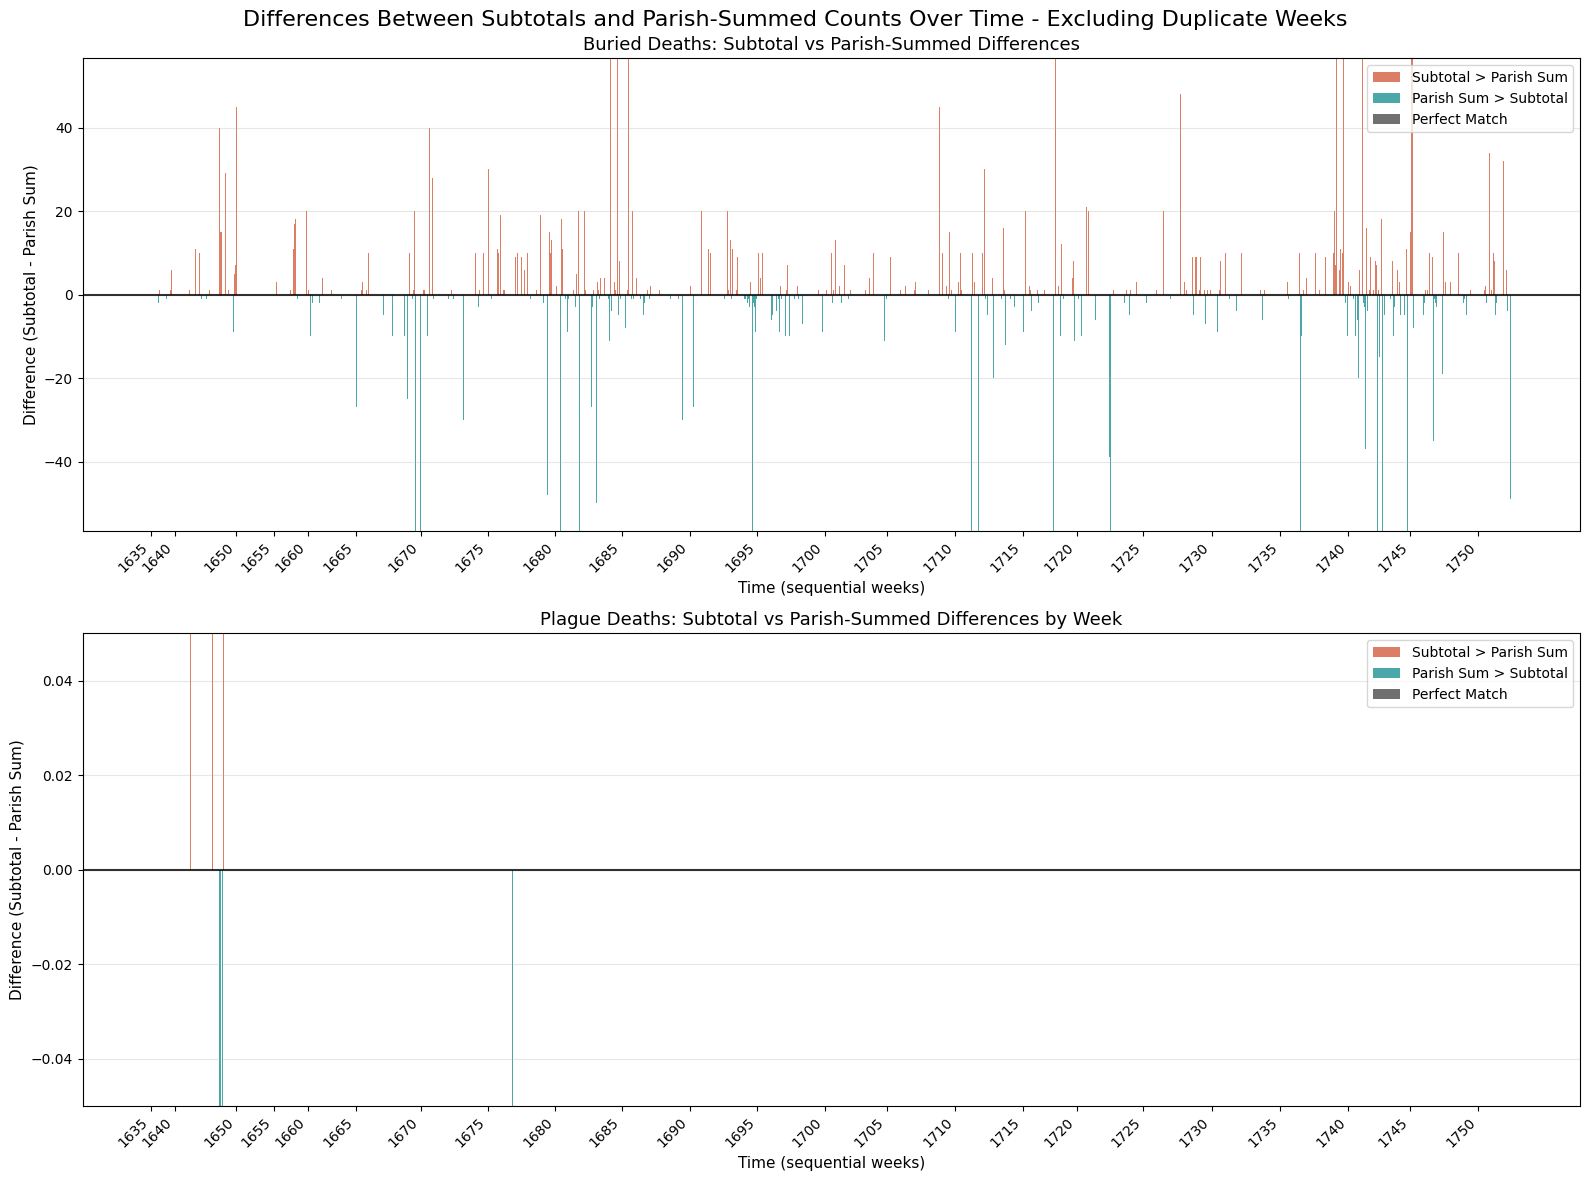

In [31]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Differences Between Subtotals and Parish-Summed Counts Over Time - Excluding Duplicate Weeks', fontsize=16, y=0.98)

count_types = ['buried', 'plague']
colors = ['#1f77b4', '#ff7f0e']
titles = ['Buried Deaths: Subtotal vs Parish-Summed Differences', 'Plague Deaths: Subtotal vs Parish-Summed Differences by Week']

for idx, count_type in enumerate(count_types):
    ax = ax1 if idx == 0 else ax2
    color = colors[idx]

    # Use 'comparison' dataframe
    comparison_data = comparison[comparison['count_type'] == count_type].copy()

    if len(comparison_data) == 0:
        ax.text(0.5, 0.5, f'No data available for {count_type}', ha='center', va='center', transform=ax.transAxes)
        continue

    comparison_data = comparison_data.sort_values(['year', 'week_number']).reset_index(drop=True)
    comparison_data['time_index'] = range(len(comparison_data))

    # Color bars based on positive/negative
    colors_bars = ['#cc4824' if x > 0 else '#008285' if x < 0 else '#333333' for x in comparison_data['difference']]

    bars = ax.bar(comparison_data['time_index'], comparison_data['difference'], width=1.0, alpha=0.7, color=colors_bars)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.8, label='Perfect Match (0)')

    ax.set_xlabel('Time (sequential weeks)', fontsize=11)
    ax.set_ylabel('Difference (Subtotal - Parish Sum)', fontsize=11)
    ax.set_title(titles[idx], fontsize=13)

    # Add legend explaining the colors
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#cc4824', alpha=0.7, label='Subtotal > Parish Sum'),
        Patch(facecolor='#008285', alpha=0.7, label='Parish Sum > Subtotal'),
        Patch(facecolor='#333333', alpha=0.7, label='Perfect Match')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')

    # Year markers - show every 5 years or adjust based on data range
    if len(comparison_data) > 0:
        year_positions = []
        year_labels = []
        current_year = None
        year_range = comparison_data['year'].max() - comparison_data['year'].min()
        year_step = 5 if year_range > 50 else 2  # Adjust step based on range

        for i, row in comparison_data.iterrows():
            if current_year is None or row['year'] != current_year:
                if current_year is None or int(row['year']) % year_step == 0:
                    year_positions.append(i)
                    year_labels.append(str(int(row['year'])))
                current_year = row['year']

        if year_positions:
            ax.set_xticks(year_positions)
            ax.set_xticklabels(year_labels, rotation=45, ha='right')

    # Set y-axis limits
    q1 = comparison_data['difference'].quantile(0.01)
    q99 = comparison_data['difference'].quantile(0.99)
    y_range = max(abs(q1), abs(q99))
    ax.set_ylim(-y_range * 1.1, y_range * 1.1)

plt.tight_layout()
plt.show()

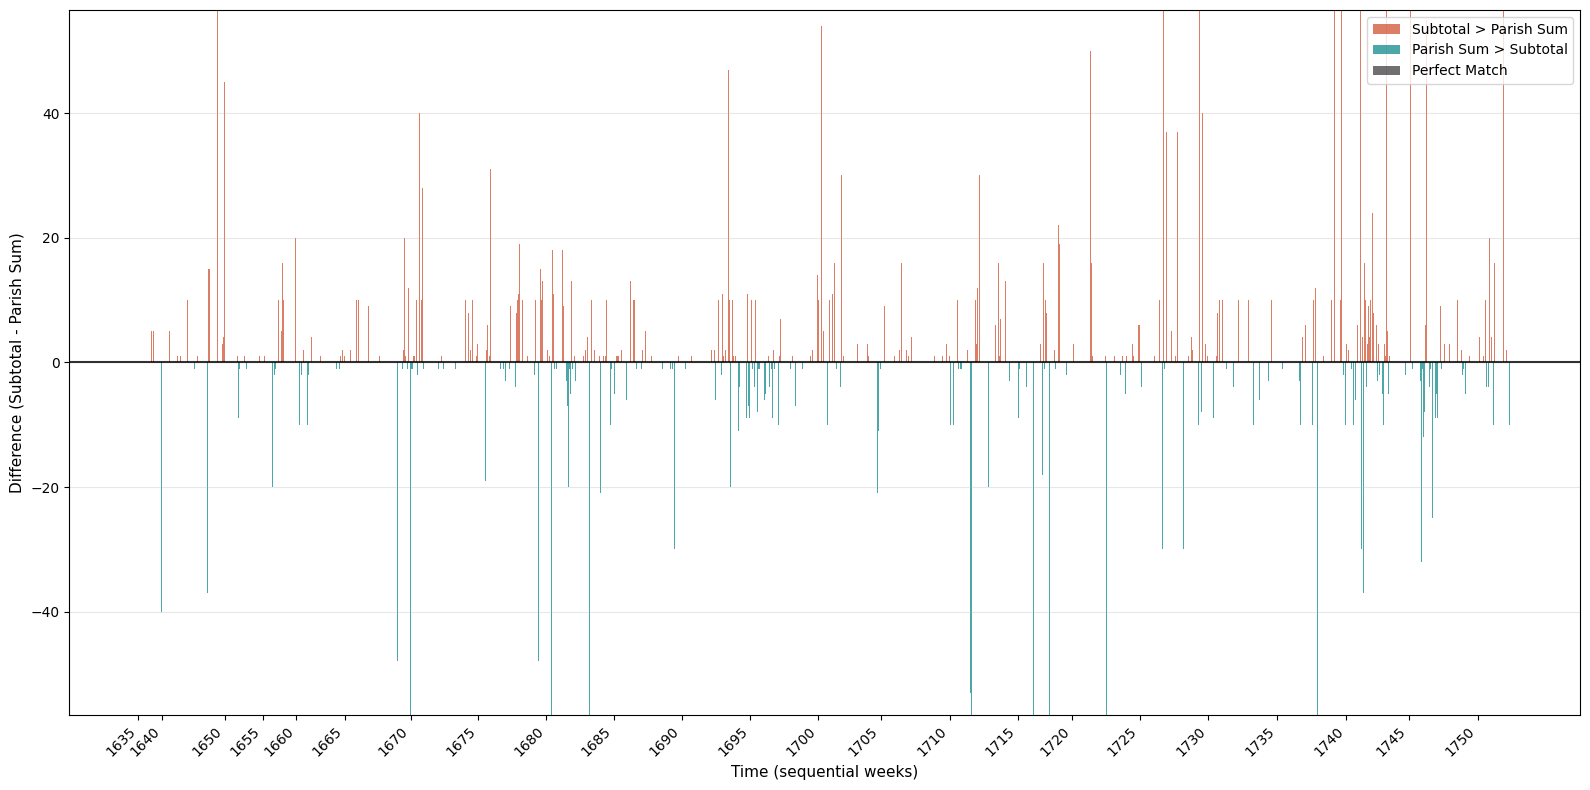

In [32]:
# A version of the above chart, just burials and captions removed.
fig, ax1 = plt.subplots(1, 1, figsize=(16, 8))
# fig.suptitle('Differences Between Subtotals and Parish-Summed Counts Over Time - Excluding Duplicate Weeks', fontsize=16, y=0.98)

count_types = ['buried']
colors = ['#1f77b4']
#titles = ['Buried Deaths: Subtotal vs Parish-Summed Differences']

for idx, count_type in enumerate(count_types):
    ax = ax1
    color = colors[idx]

    # Use 'comparison' dataframe
    comparison_data = comparison[comparison['count_type'] == count_type].copy()

    if len(comparison_data) == 0:
        ax.text(0.5, 0.5, f'No data available for {count_type}', ha='center', va='center', transform=ax.transAxes)
        continue

    comparison_data = comparison_data.sort_values(['year', 'week_number']).reset_index(drop=True)
    comparison_data['time_index'] = range(len(comparison_data))

    # Color bars based on positive/negative
    colors_bars = ['#cc4824' if x > 0 else '#008285' if x < 0 else '#333333' for x in comparison_data['difference']]

    bars = ax.bar(comparison_data['time_index'], comparison_data['difference'], width=1.0, alpha=0.7, color=colors_bars)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.8, label='Perfect Match (0)')

    ax.set_xlabel('Time (sequential weeks)', fontsize=11)
    ax.set_ylabel('Difference (Subtotal - Parish Sum)', fontsize=11)
    #ax.set_title(titles[idx], fontsize=13)

    # Add legend explaining the colors
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#cc4824', alpha=0.7, label='Subtotal > Parish Sum'),
        Patch(facecolor='#008285', alpha=0.7, label='Parish Sum > Subtotal'),
        Patch(facecolor='#333333', alpha=0.7, label='Perfect Match')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')

    # Year markers - show every 5 years or adjust based on data range
    if len(comparison_data) > 0:
        year_positions = []
        year_labels = []
        current_year = None
        year_range = comparison_data['year'].max() - comparison_data['year'].min()
        year_step = 5 if year_range > 50 else 2  # Adjust step based on range

        for i, row in comparison_data.iterrows():
            if current_year is None or row['year'] != current_year:
                if current_year is None or int(row['year']) % year_step == 0:
                    year_positions.append(i)
                    year_labels.append(str(int(row['year'])))
                current_year = row['year']

        if year_positions:
            ax.set_xticks(year_positions)
            ax.set_xticklabels(year_labels, rotation=45, ha='right')

    # Set y-axis limits
    q1 = comparison_data['difference'].quantile(0.01)
    q99 = comparison_data['difference'].quantile(0.99)
    y_range = max(abs(q1), abs(q99))
    ax.set_ylim(-y_range * 1.1, y_range * 1.1)

plt.tight_layout()
plt.show()

In [34]:
# TODO: Illegible weeks by decade
comparison['decade'] = (comparison['year'] // 10) * 10

# Group by decade and calculate the mean percentage of illegible weeks
decade_illegibility = comparison.groupby('decade')['pct_weeks_illegible'].mean().reset_index() # update

# Convert 'decade' to integer type for cleaner display on x-axis
decade_illegibility['decade'] = decade_illegibility['decade'].astype(int)

plt.figure(figsize=(14, 7))
sns.barplot(data=decade_illegibility, x='decade', y='pct_weeks_illegible', color=PALETTE[5]) # update
plt.title('Percentage of Illegible Weekly Bills by Decade')
plt.xlabel('Decade')
plt.ylabel('Mean % Illegible Weekly Bills')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

KeyError: 'Column not found: pct_weeks_illegible'

We can examine our data by specific year ranges as well, by setting the `YEAR_START` and `YEAR_END` parameters.

In [ ]:
# === CONFIGURATION ===
YEAR_START = 1700
YEAR_END = 1740
USE_YEAR_FILTER = True  # Set to False to see all years

# === PLOTTING ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

if USE_YEAR_FILTER:
    fig.suptitle(f'Differences Between Subtotals and Parish-Summed Counts ({YEAR_START}-{YEAR_END})', fontsize=16, y=0.98)
else:
    fig.suptitle('Differences Between Subtotals and Parish-Summed Counts (All Years)', fontsize=16, y=0.98)

count_types = ['buried', 'plague']
titles = ['Buried Deaths: Subtotal vs Parish-Summed Differences', 'Plague Deaths: Subtotal vs Parish-Summed Differences']

for idx, count_type in enumerate(count_types):
    ax = ax1 if idx == 0 else ax2

    comparison_data = comparison[comparison['count_type'] == count_type].copy()

    # Apply year filter if enabled
    if USE_YEAR_FILTER:
        comparison_data = comparison_data[(comparison_data['year'] >= YEAR_START) & (comparison_data['year'] <= YEAR_END)]

    if len(comparison_data) == 0:
        ax.text(0.5, 0.5, f'No data available for {count_type}', ha='center', va='center', transform=ax.transAxes)
        continue

    comparison_data = comparison_data.sort_values(['year', 'week_number']).reset_index(drop=True)

    # Color bars based on positive/negative
    colors_bars = ['#cc4824' if x > 0 else '#008285' if x < 0 else '#333333' for x in comparison_data['difference']]

    # Decide whether to use week numbers or sequential index based on year range
    year_range = YEAR_END - YEAR_START if USE_YEAR_FILTER else comparison_data['year'].max() - comparison_data['year'].min()

    if USE_YEAR_FILTER and year_range <= 2:
        # For 1-2 years, use week_number on x-axis
        if year_range <= 1:
            # Single year: just show week numbers
            x_values = comparison_data['week_number']
            ax.set_xlabel('Week Number', fontsize=11)
        else:
            # Multiple years: create combined year-week identifier
            comparison_data['year_week'] = comparison_data['year'].astype(str) + '-W' + comparison_data['week_number'].astype(int).astype(str)
            comparison_data['x_pos'] = range(len(comparison_data))
            x_values = comparison_data['x_pos']
            ax.set_xlabel('Week (Year-Week)', fontsize=11)

        bars = ax.bar(x_values, comparison_data['difference'], width=0.8, alpha=0.7, color=colors_bars)

        if year_range <= 1:
            # Show every 5th week for single year
            ax.set_xticks(range(0, int(comparison_data['week_number'].max()) + 1, 5))
        else:
            # Show year boundaries for multi-year
            year_positions = []
            year_labels = []
            current_year = None
            for i, row in comparison_data.iterrows():
                if row['year'] != current_year:
                    year_positions.append(row['x_pos'])
                    year_labels.append(f"{int(row['year'])}")
                    current_year = row['year']
            if year_positions:
                ax.set_xticks(year_positions)
                ax.set_xticklabels(year_labels, rotation=0)
    else:
        # For many years, use sequential time index
        comparison_data['time_index'] = range(len(comparison_data))
        bars = ax.bar(comparison_data['time_index'], comparison_data['difference'], width=1.0, alpha=0.7, color=colors_bars)
        ax.set_xlabel('Time (sequential weeks)', fontsize=11)

        # Year markers - show every 5 years or adjust based on data range
        year_positions = []
        year_labels = []
        current_year = None
        year_step = 5 if year_range > 50 else 2  # Adjust step based on range

        for i, row in comparison_data.iterrows():
            if current_year is None or row['year'] != current_year:
                if current_year is None or int(row['year']) % year_step == 0:
                    year_positions.append(i)
                    year_labels.append(str(int(row['year'])))
                current_year = row['year']

        if year_positions:
            ax.set_xticks(year_positions)
            ax.set_xticklabels(year_labels, rotation=45, ha='right')

    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
    ax.set_ylabel('Difference (Subtotal - Parish Sum)', fontsize=11)
    ax.set_title(titles[idx], fontsize=13)

    # Add legend explaining the colors
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#cc4824', alpha=0.7, label='Subtotal > Parish Sum'),
        Patch(facecolor='#008285', alpha=0.7, label='Parish Sum > Subtotal'),
        Patch(facecolor='#333333', alpha=0.7, label='Perfect Match')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')

    # Set y-axis limits
    q1 = comparison_data['difference'].quantile(0.01)
    q99 = comparison_data['difference'].quantile(0.99)
    y_range = max(abs(q1), abs(q99))
    ax.set_ylim(-y_range * 1.1, y_range * 1.1)

    # make the y axis use whole numbers
    from matplotlib.ticker import MaxNLocator
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

# Exports and Sum Checks

In [ ]:
comparison.to_excel('comparison.xlsx', index=False, sheet_name='comparison')

In [ ]:
# Using the 'comparison' DataFrame, filter to show rows where the
# subtotal and parish sum do not match and then list the unique sources
# involved in those discrepancies.

# Filter for rows where the difference is not zero
mismatched_rows = comparison[comparison['difference'] != 0].copy()

print(f"Shape of comparison before merges: {comparison.shape}")
print(f"Shape of weekly_subtotals_sum before merge: {weekly_subtotals_sum.shape}")
print(f"Shape of subtotals before merge: {subtotals[['year', 'joinid', 'count_type', 'source']].drop_duplicates().shape}")

# Merge comparison with weekly_subtotals_sum
# This merge should be 1:1 based on year, week_number, count_type
merged_comparison = comparison.merge(
    weekly_subtotals_sum,
    on=['year', 'week_number', 'count_type'],
    how='inner' # Use inner merge to keep only matching rows
)
print(f"Shape after merging with weekly_subtotals_sum: {merged_comparison.shape}")

# Now merge the result with subtotals to get the joinid and source
# We need to be careful here as there might be multiple joinids/sources for a given year/week/count_type
# Let's keep only the necessary columns from subtotals to avoid unintended duplicates in this step
subtotals_for_merge = subtotals[['year', 'week_number', 'count_type', 'joinid', 'source']].drop_duplicates()

mismatched_with_source = merged_comparison.merge(
    subtotals_for_merge,
    on=['year', 'week_number', 'count_type'],
    how='left' # Use left merge to keep all rows from merged_comparison
)
print(f"Shape after merging with subtotals for source: {mismatched_with_source.shape}")

# Filter for rows where the difference is not zero
mismatched_sources_df = mismatched_with_source[mismatched_with_source['difference'] != 0].copy()
# find just count_type = plague
# mismatched_sources_df = mismatched_sources_df[mismatched_sources_df['count_type'] == 'plague']
mismatched_sources_df.sort_values('year').tail(30)

In [ ]:
# save our mismatched data to an Excel file for closer examination
# mismatched_sources_df.to_excel('discrepancies.xlsx', index=False, sheet_name='summary')

In [ ]:
# check all_bills for year = 1730 week = 40 -- should be empty!
bills[bills['year'] == 1730][bills['week_number'] == 40][bills['count_type'] == 'plague']

In [ ]:
# Define the source to filter by
SOURCE_FILTER = 'BodleianV1-weeklybills'

# Filter bills and subtotals_df by the specified source
bills_filtered = bills[bills['source'].str.contains(SOURCE_FILTER, na=False)].copy()
subtotals_filtered = subtotals_df[subtotals_df['source'].str.contains(SOURCE_FILTER, na=False)].copy()

# Merge the filtered subtotals with the weeks dataframe to bring in week_number
# Use weeks_df (the DataFrame read earlier) in case 'weeks' was overwritten as a list
if 'weeks_df' in globals():
    weeks_to_merge = weeks[['joinid', 'week_number']]
else:
    # fallback: reload weeks if needed
    weeks_to_merge = pd.read_csv(Path('weeks.csv'))[['joinid', 'week_number']]

subtotals_filtered = subtotals_filtered.merge(
    weeks_to_merge,
    on='joinid',
    how='left'
)


# Sum the parish counts for the filtered data
data_frames_filtered = []

# Process buried data for filtered bills
if 'count' in bills_filtered.columns and 'count_type' in bills_filtered.columns:
    buried_data_filtered = bills_filtered[bills_filtered['count_type'] == 'buried']
    buried_totals_filtered = buried_data_filtered.groupby(['year', 'week_number'])['count'].sum().reset_index()
    buried_totals_filtered['count_type'] = 'buried'
    data_frames_filtered.append(buried_totals_filtered)

# Process plague data for filtered bills
if 'count' in bills_filtered.columns and 'count_type' in bills_filtered.columns:
    plague_data_filtered = bills_filtered[bills_filtered['count_type'] == 'plague']
    plague_totals_filtered = plague_data_filtered.groupby(['year', 'week_number'])['count'].sum().reset_index()
    plague_totals_filtered['count_type'] = 'plague'
    data_frames_filtered.append(plague_totals_filtered)

# Combine all filtered data
weekly_totals_filtered = pd.concat(data_frames_filtered, ignore_index=True)

# Sum the subtotals for the filtered data
weekly_subtotals_sum_filtered = (
    subtotals_filtered
    .groupby(['year', 'week_number', 'count_type'], dropna=False)['count']
    .sum()
    .reset_index(name='subtotal_sum')
)

# Merge with calculated totals for comparison
comparison_filtered = weekly_subtotals_sum_filtered.merge(
    weekly_totals_filtered.rename(columns={'count': 'calculated_total'}),
    on=['year', 'week_number', 'count_type'],
    how='outer'
)

# Calculate differences
comparison_filtered['calculated_total'] = comparison_filtered['calculated_total'].fillna(0).astype(int)
comparison_filtered['subtotal_sum'] = comparison_filtered['subtotal_sum'].fillna(0).astype(int)
comparison_filtered['difference'] = comparison_filtered['subtotal_sum'] - comparison_filtered['calculated_total']
comparison_filtered['matches'] = comparison_filtered['difference'] == 0

# Sort by year, week, and count_type
comparison_filtered = comparison_filtered.sort_values(['year', 'week_number', 'count_type']).reset_index(drop=True)

print(f"Comparison for source: {SOURCE_FILTER}")
print(f"\nTotal comparisons: {len(comparison_filtered):,}; Exact matches: {comparison_filtered['matches'].sum():,} ({comparison_filtered['matches'].mean()*100:.1f}%)")
print("\nFirst 20 rows of comparison:")
display(comparison_filtered[['year', 'week_number', 'count_type', 'subtotal_sum', 'calculated_total', 'difference', 'matches']].head(20))